<a href="https://colab.research.google.com/github/SamuelMbogo/Colab_projects/blob/main/Introduction_to_Quantitative_Finance(Rhea).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CASE STUDY 1


[*********************100%***********************]  4 of 4 completed
<ipython-input-1-25ba08bf499d>:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nasdaq_data['3Month Moving Average'] = nasdaq_data[target_column].rolling(window=3).mean()
<ipython-input-1-25ba08bf499d>:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nasdaq_data['36Month Moving Average'] = nasdaq_data[target_column].rolling(window=36).mean()


Returns for first 5 months:
 Date
2004-12-31    0.032458
2005-01-31   -0.025290
2005-02-28    0.018903
2005-03-31   -0.019118
2005-04-30   -0.020109
Freq: ME, Name: Close, dtype: float64
Returns for last 5 months:
 Date
2024-08-31    0.022835
2024-09-30    0.020197
2024-10-31   -0.009897
2024-11-30    0.057301
2024-12-31   -0.020794
Freq: ME, Name: Close, dtype: float64
20-Year compounded return: 403.22%
Annualized Return: 8.08%


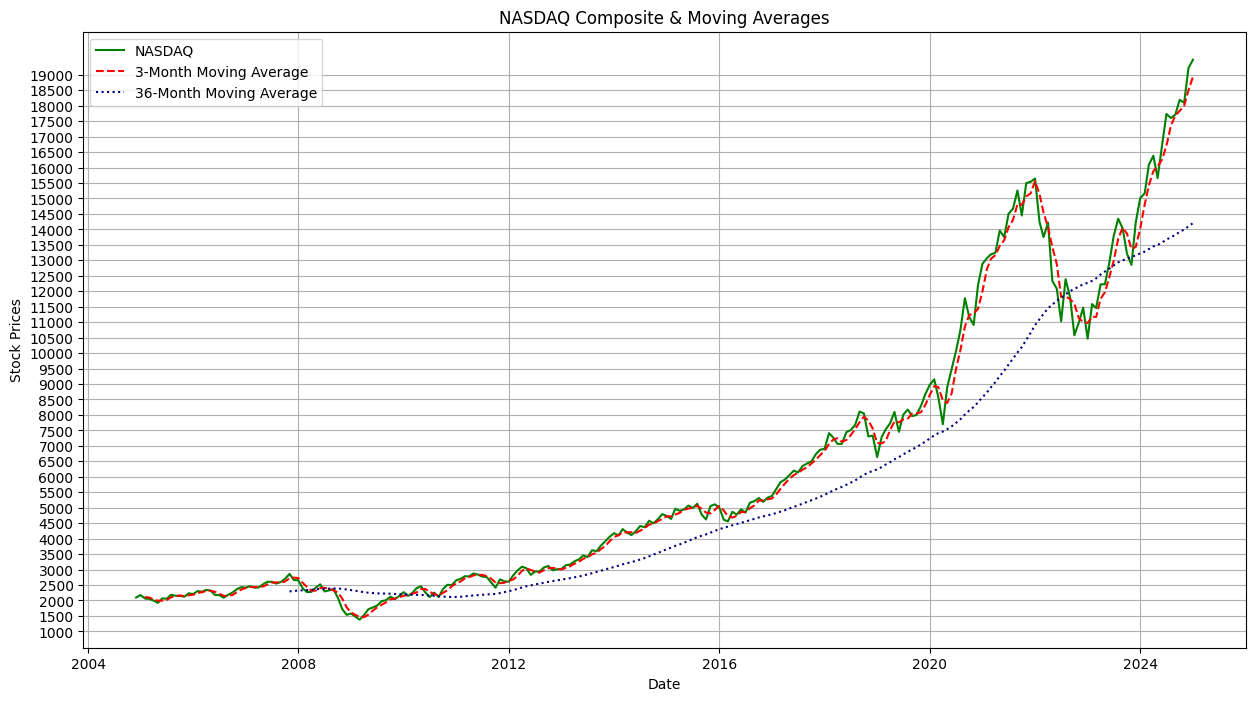

CASE STUDY 2
Premium for long call: 18.1408
Premium for short call: 12.336
Premium for long put: 12.6616
Premium for short put: 7.4589


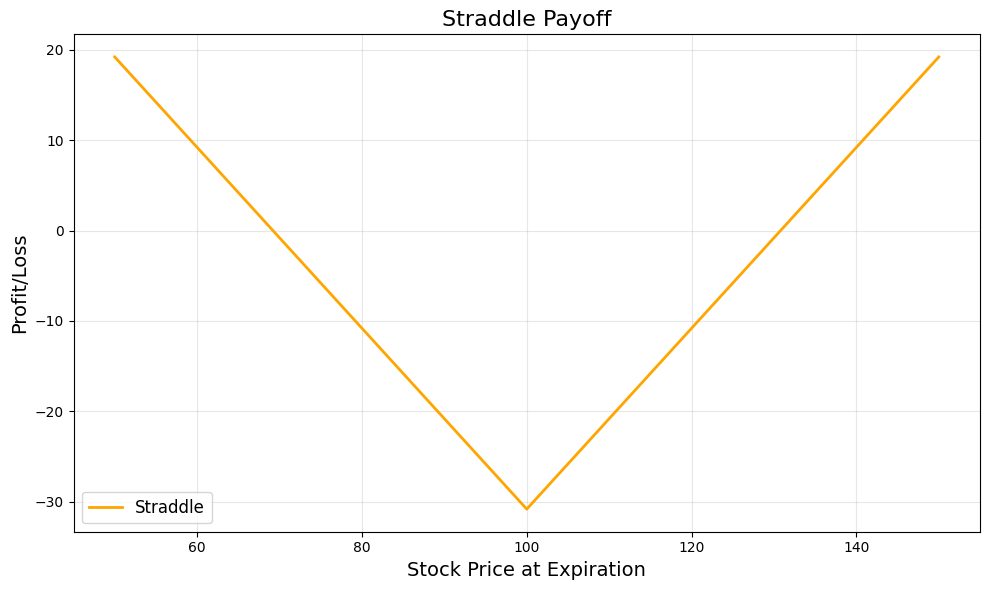

Break-even point for bull call strategy: 95.8048
Profit for bull call strategy: 4.195200000000002
Loss for bull call strategy: 5.804799999999998
Break-even point for bear put strategy: 104.7973
Profit for bear put strategy: 4.7973
Loss for bear put strategy: 5.2027


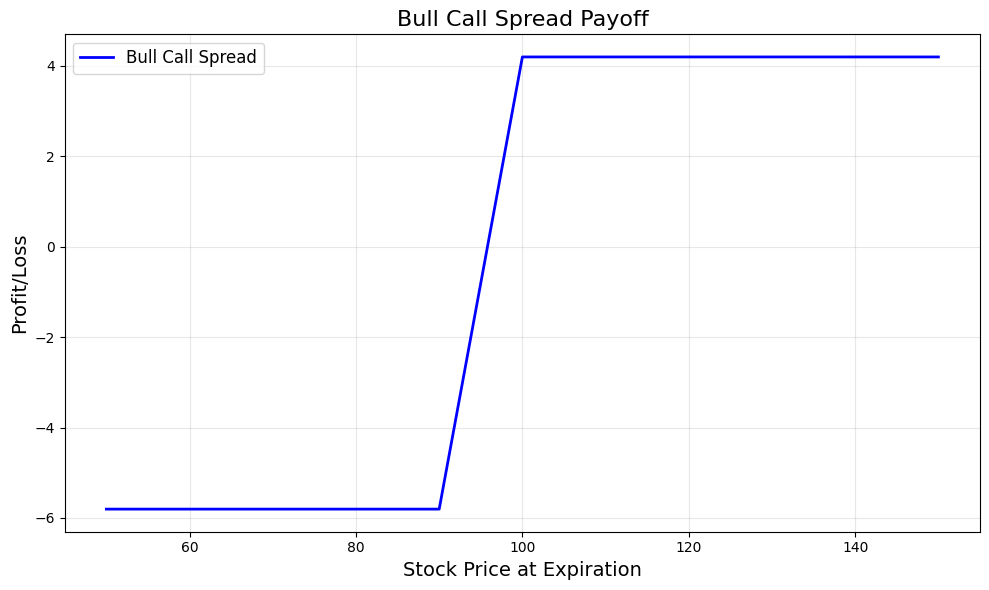

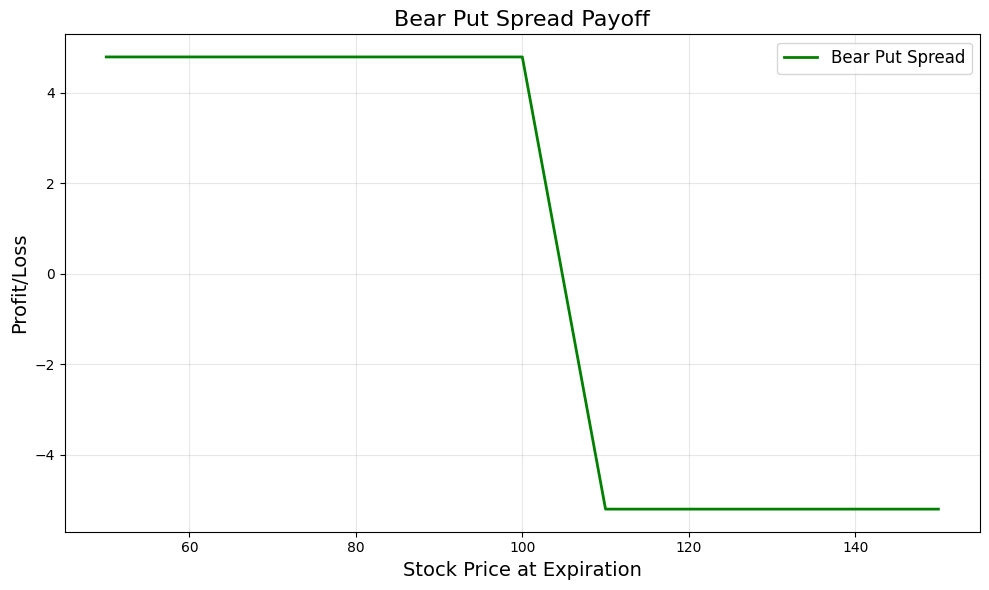

array([ 4.7973,  4.7973,  4.7973,  4.7973,  4.7973,  4.7973,  4.7973,
        4.7973,  4.7973,  4.7973,  4.7973, -0.2027, -5.2027, -5.2027,
       -5.2027, -5.2027, -5.2027, -5.2027, -5.2027, -5.2027, -5.2027])

In [1]:
# Case Study 1
print('CASE STUDY 1')

# Importing necessary libraries

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

#1.1

# Data staging
tickers = ['^SPX', '^IXIC', '^VIX', '^IRX']
start="2004-11-01"
end="2024-12-31"

data=yf.download(tickers,start=start, end=end)

#`^SPX:` S&P 500 Index
#`^IXIC:` NASDAQ Composite
#`^VIX:` Volatility Index
#`^IRX:` 13-Week Treasury Bill Rate
#The data spans from November 1, 2004, to December 31, 2024.

# Resampling the data to include only month-end values
month_end_data = data.resample('ME').last()

# Select SPX data for analysis
spx_data = month_end_data.xs("^SPX", level=1, axis=1)
spx_data

# Monthly Return:
def calculate_monthly_returns(data):
    return data['Close'].pct_change().dropna()

monthly_returns= calculate_monthly_returns(spx_data)
print("Returns for first 5 months:\n", monthly_returns.head())
print("Returns for last 5 months:\n", monthly_returns.tail())


# 20-Year compounded return:
def compounded_return(returns):
    return (1 + returns).prod() - 1

comp_return=compounded_return(monthly_returns)
print(f"20-Year compounded return: {comp_return:.2%}")

# Annualized Return: (using natural logarithm method)
def annualized_return(compounded_return, years):
    return np.log(1 + compounded_return) / years
years=20

annual_return=annualized_return(comp_return, years)
print(f"Annualized Return: {annual_return:.2%}")

# 1.2- Calculating moving averages (MA) for NASDAQ composite
# Assuming 'monthly_data' is a DataFrame with NASDAQ data
nasdaq_data = month_end_data.xs("^IXIC", level=1, axis=1)
nasdaq_data

# Determine the target column (case-sensitive check)
if 'Adj Close' in nasdaq_data.columns:
    target_column = 'Adj Close'
else:
    target_column = 'Close'

# Calculate moving averages
nasdaq_data['3Month Moving Average'] = nasdaq_data[target_column].rolling(window=3).mean()
nasdaq_data['36Month Moving Average'] = nasdaq_data[target_column].rolling(window=36).mean()

# Plotting the data{
plt.figure(figsize=(15, 8))
plt.plot(nasdaq_data.index, nasdaq_data[target_column], label="NASDAQ", color='green', alpha=1)
plt.plot(nasdaq_data.index, nasdaq_data['3Month Moving Average'], label="3-Month Moving Average", color='red', linestyle='--', alpha=1)
plt.plot(nasdaq_data.index, nasdaq_data['36Month Moving Average'], label="36-Month Moving Average", color='navy', linestyle=':', alpha=1)

# Add title and labels
plt.title("NASDAQ Composite & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Stock Prices")

# Set y-axis ticks
min_price = nasdaq_data[target_column].min()
max_price = nasdaq_data[target_column].max()
y_ticks = np.arange(int(min_price // 500) * 500, int(max_price // 500 + 1) * 500, 500)
plt.yticks(y_ticks)

# Add legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

# Case Study 2
print("CASE STUDY 2")

# Parameters
S = np.arange(50, 155, 5)
K1, K2, K3 = 90, 100, 110
T = 1
r = 0.05
sigma = 0.25

# Option price calculation
def option_prices(S, K, r, sigma, T, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    Nd1 = norm.cdf(d1)
    Nd2 = norm.cdf(d2)
    Nminusd1 = norm.cdf(-d1)
    Nminusd2 = norm.cdf(-d2)

    if option_type == 'call':
        option_price = round(S * Nd1 - K * np.exp(-r * T) * Nd2, 4)
    elif option_type == 'put':
        option_price = round(K * np.exp(-r * T) * Nminusd2 - S * Nminusd1, 4)
    else:
        raise ValueError("Invalid option_type. Use 'call' or 'put'.")
    return option_price

# Bull-Call strategy
premium_long_call = option_prices(S=100, K=K1, r=r, sigma=sigma, T=T, option_type='call')
premium_short_call = option_prices(S=100, K=K2, r=r, sigma=sigma, T=T, option_type='call')
print("Premium for long call:", premium_long_call)
print("Premium for short call:", premium_short_call)

# Bear-put strategy
premium_long_put = option_prices(S=100, K=K3, r=r, sigma=sigma, T=T, option_type='put')
premium_short_put = option_prices(S=100, K=K2, r=r, sigma=sigma, T=T, option_type='put')
print("Premium for long put:", premium_long_put)
print("Premium for short put:", premium_short_put)

# Net premiums
net_premium_bull = premium_long_call - premium_short_call
net_premium_bear = premium_long_put - premium_short_put

# Bull-Call Spread Payoff
def bull_call_spread_payoff(S, K1, K2, premium_long_call, premium_short_call):
    long_call = np.maximum(S - K1, 0) - premium_long_call
    short_call = np.maximum(S - K2, 0) - premium_short_call
    payoff = long_call - short_call

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(S, payoff, label="Bull Call Spread", color="blue", linewidth=2)
    ax.set_title("Bull Call Spread Payoff", fontsize=16)
    ax.set_xlabel("Stock Price at Expiration", fontsize=14)
    ax.set_ylabel("Profit/Loss", fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return payoff

# Bear-Put Spread Payoff
def bear_put_spread_payoff(S, K2, K3, premium_long_put, premium_short_put):
    long_put = np.maximum(K3 - S, 0) - premium_long_put
    short_put = np.maximum(K2 - S, 0) - premium_short_put
    payoff = long_put - short_put

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(S, payoff, label="Bear Put Spread", color="green", linewidth=2)
    ax.set_title("Bear Put Spread Payoff", fontsize=16)
    ax.set_xlabel("Stock Price at Expiration", fontsize=14)
    ax.set_ylabel("Profit/Loss", fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return payoff

# Straddle Payoff
def straddle(S, K2, premium_long_call, premium_long_put):
    long_call = np.maximum(S - K2, 0) - premium_long_call
    long_put = np.maximum(K2 - S, 0) - premium_long_put
    payoff = long_call + long_put

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(S, payoff, label="Straddle", color="orange", linewidth=2)
    ax.set_title("Straddle Payoff", fontsize=16)
    ax.set_xlabel("Stock Price at Expiration", fontsize=14)
    ax.set_ylabel("Profit/Loss", fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return payoff

straddle(S, K2, premium_long_call, premium_long_put)

# Calculate breakeven and profit/loss for strategies
break_even_point_bull_call = K1 + net_premium_bull
profit_bull_call = K2 - K1 - net_premium_bull
loss_bull_call = net_premium_bull
print("Break-even point for bull call strategy:", break_even_point_bull_call)
print("Profit for bull call strategy:", profit_bull_call)
print("Loss for bull call strategy:", loss_bull_call)

break_even_point_bear_put = K3 - net_premium_bear
profit_bear_put = K3 - K2 - net_premium_bear
loss_bear_put = net_premium_bear
print("Break-even point for bear put strategy:", break_even_point_bear_put)
print("Profit for bear put strategy:", profit_bear_put)
print("Loss for bear put strategy:", loss_bear_put)

# Visualization
bull_call_spread_payoff(S, K1, K2, premium_long_call, premium_short_call)
bear_put_spread_payoff(S, K2, K3, premium_long_put, premium_short_put)